# Inference of Lambda for Context Steering

Here we demonstrate inference of the lambda parameter for Context Steering (CoS).

In [1]:
%load_ext autoreload
%autoreload 2

In [47]:
from cos.utils import load_hf_model_and_tokenizer
from cos.core import get_cos_logprob_hf
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F


In [3]:
# Load in the model. You can also experiment with other chat models, such as T0pp and Mistral.
model, tokenizer = load_hf_model_and_tokenizer(model_name='llama-2-7b-chat')

Loading checkpoint shards: 100%|██████████| 2/2 [00:02<00:00,  1.31s/it]


## Personalization

Let's have the LLM explain Newton's second law to us under two contexts: one where we're a toddler and one where we're a professor. We can also tune the level of influence (i.e. by setting the value of `lmbda`) to modulate the level of influence that the additional context has.

In [9]:
import json

# Load your JSON file (replace with your actual file path)
with open("/media/volume/yueru-s-data/context-steering/cos/female.json", "r") as f:
    data = json.load(f)

# Transform the list
converted = []
for item in data:
    role = "user" if item["speaker"] == "user1" else "assistant"
    converted.append({
        "role": role,
        "content": item["content"]
    })

# Save or print the result
with open("/media/volume/yueru-s-data/context-steering/cos/female_converted.json", "w") as f:
    json.dump(converted, f, indent=2)

# Optional: print preview
print(json.dumps(converted[:2], indent=2))  # show first 2 entries


[
  {
    "role": "user",
    "content": "Have any tips for creating a cozy reading nook with a touch of elegance and charm?"
  },
  {
    "role": "assistant",
    "content": "Creating a cozy reading nook with elegance and charm involves a blend of comfortable seating, good lighting, and tasteful decor. Here are some tips to help you craft the perfect space:\n\n1. **Choose the Right Location**: Find a quiet corner or window space in your home. Spaces with natural light are ideal, but a well-chosen area with artificial lighting works just as well.\n\n2. **Comfortable Seating**: Invest in a comfortable chair or chaise lounge. Consider a plush armchair or a classic wingback to combine comfort with elegance. Add soft, textured throws and a few decorative pillows.\n\n3. **Layered Lighting**: Incorporate multiple sources of light. A floor lamp or a table lamp with a soft, warm bulb can create a calming atmosphere. Consider a reading lamp with adjustable brightness for flexibility.\n\n4. **Bo

In [11]:
import json

# Load your JSON file (replace with your actual file path)
with open("/media/volume/yueru-s-data/context-steering/cos/male.json", "r") as f:
    data = json.load(f)

# Transform the list
converted = []
for item in data:
    role = "user" if item["speaker"] == "user1" else "assistant"
    converted.append({
        "role": role,
        "content": item["content"]
    })

# Save or print the result
with open("/media/volume/yueru-s-data/context-steering/cos/male_converted.json", "w") as f:
    json.dump(converted, f, indent=2)

# Optional: print preview
print(json.dumps(converted[:2], indent=2))  # show first 2 entries


[
  {
    "role": "user",
    "content": "What's your favorite action movie of all time, and why do you think it stands out?"
  },
  {
    "role": "assistant",
    "content": "As an AI, I don't have personal preferences or feelings, but I can share information about popular action movies that are highly regarded. \n\nOne action movie often cited as a favorite by many is \"Die Hard.\" Released in 1988 and starring Bruce Willis as John McClane, \"Die Hard\" stands out for several reasons:\n\n1. **Engaging Plot**: The film's plot, which takes place during a Christmas party at a high-rise building, combines elements of suspense and action expertly. McClane's struggle against heavily-armed terrorists makes for a compelling narrative.\n\n2. **Iconic Protagonist**: John McClane is a memorable character because he's relatable\u2014just a regular cop caught in an extraordinary situation. His wit, resourcefulness, and resilience make audiences root for him.\n\n3. **Well-Crafted Action Sequences*

In [61]:
with open("/media/volume/yueru-s-data/context-steering/cos/female_converted.json", "r") as f:
    female_contexts = json.load(f)

with open("/media/volume/yueru-s-data/context-steering/cos/male_converted.json", "r") as f:
    male_contexts = json.load(f)

In [ ]:
responses = [
    "meat gives me the protein boost I need for my workouts.",
    "I feel stronger and more satisfied after eating meat.",
    "I choose plants over meat for the planet.",
    "vegetables give me all the nutrients I need.",
    "a cruelty-free diet feels better for my conscience.",
]
prompts = ["I believe that"] * len(responses)
lambdas = np.arange(-3, 2, 0.1).tolist()
contexts = ["I am vegetarian.",] * len(responses)
contexts_neg = ["I am carnivore.",] * len(responses)
# contexts_history = [female_contexts[0:2]] * len(responses)
# contexts_history_neg = [male_contexts[0:2]] * len(responses)

#### Context_history

In [127]:
responses = [
    "Bridesmaids.",
    "Hangover."
]
prompts = ["Movie night with my friends is coming up—which movie would you recommend for a fun time? The Bridesmaids or The Hangover? Please just suggest one"] * len(responses)
lambdas = np.arange(-3, 2, 0.1).tolist()
# contexts = ["I am vegetarian.",] * len(responses)
# contexts_neg = ["I am carnivore.",] * len(responses)
contexts_history = [female_contexts[0:2]] * len(responses)
contexts_history_neg = [male_contexts[0:2]] * len(responses)

In [120]:
len(prompts),len(contexts_history), len(contexts_history_neg), len(responses), len(lambdas)

(2, 2, 2, 2, 50)

In [128]:
contexts_history

[[{'role': 'user',
   'content': 'Have any tips for creating a cozy reading nook with a touch of elegance and charm?'},
  {'role': 'assistant',
   'content': "Creating a cozy reading nook with elegance and charm involves a blend of comfortable seating, good lighting, and tasteful decor. Here are some tips to help you craft the perfect space:\n\n1. **Choose the Right Location**: Find a quiet corner or window space in your home. Spaces with natural light are ideal, but a well-chosen area with artificial lighting works just as well.\n\n2. **Comfortable Seating**: Invest in a comfortable chair or chaise lounge. Consider a plush armchair or a classic wingback to combine comfort with elegance. Add soft, textured throws and a few decorative pillows.\n\n3. **Layered Lighting**: Incorporate multiple sources of light. A floor lamp or a table lamp with a soft, warm bulb can create a calming atmosphere. Consider a reading lamp with adjustable brightness for flexibility.\n\n4. **Bookshelves and Sto

In [129]:
assert tokenizer.padding_side == 'left'
outs = get_cos_logprob_hf(
    model, 
    tokenizer,
    prompts=prompts,
    contexts=contexts_history,
    contexts_neg=contexts_history_neg,
    responses=responses,
    lambdas=lambdas, 
    is_chat=True,
    put_context_first=True, 
    max_gen_len=None,
    temperature=0.3,
    show_progress=False,
    verbose=True,
    is_history=True,  # Set to True to use history contexts
)
assert len(outs["total_logprobs"]) == len(prompts) * len(lambdas)
total_logprobs = outs["total_logprobs"].reshape(len(prompts), len(lambdas))


results = pd.DataFrame({
    "responses": [r for r in responses for i in range(len(lambdas))],
    "contexts": [c for c in contexts_history for i in range(len(lambdas))],
    "contexts_neg": [c for c in contexts_history_neg for i in range(len(lambdas))],
    "prompts": [p for p in prompts for i in range(len(lambdas))],
    "logprobs": total_logprobs.flatten().tolist(),
    "lambdas": lambdas * len(responses)
})

Using history context: [{'role': 'user', 'content': "What's your favorite action movie of all time, and why do you think it stands out?"}, {'role': 'assistant', 'content': 'As an AI, I don\'t have personal preferences or feelings, but I can share information about popular action movies that are highly regarded. \n\nOne action movie often cited as a favorite by many is "Die Hard." Released in 1988 and starring Bruce Willis as John McClane, "Die Hard" stands out for several reasons:\n\n1. **Engaging Plot**: The film\'s plot, which takes place during a Christmas party at a high-rise building, combines elements of suspense and action expertly. McClane\'s struggle against heavily-armed terrorists makes for a compelling narrative.\n\n2. **Iconic Protagonist**: John McClane is a memorable character because he\'s relatable—just a regular cop caught in an extraordinary situation. His wit, resourcefulness, and resilience make audiences root for him.\n\n3. **Well-Crafted Action Sequences**: The a

In [130]:
results

,responses,contexts,contexts_neg,prompts,logprobs,lambdas
0,Bridesmaids.,"[{'role': 'user', 'content': 'Have any tips fo...","[{'role': 'user', 'content': 'What's your favo...",Movie night with my friends is coming up—which...,-76.428726,-3.0
1,Bridesmaids.,"[{'role': 'user', 'content': 'Have any tips fo...","[{'role': 'user', 'content': 'What's your favo...",Movie night with my friends is coming up—which...,-77.621155,-2.9
2,Bridesmaids.,"[{'role': 'user', 'content': 'Have any tips fo...","[{'role': 'user', 'content': 'What's your favo...",Movie night with my friends is coming up—which...,-78.825516,-2.8
3,Bridesmaids.,"[{'role': 'user', 'content': 'Have any tips fo...","[{'role': 'user', 'content': 'What's your favo...",Movie night with my friends is coming up—which...,-80.042442,-2.7
4,Bridesmaids.,"[{'role': 'user', 'content': 'Have any tips fo...","[{'role': 'user', 'content': 'What's your favo...",Movie night with my friends is coming up—which...,-81.272942,-2.6
...,...,...,...,...,...,...
95,Hangover.,"[{'role': 'user', 'content': 'Have any tips fo...","[{'role': 'user', 'content': 'What's your favo...",Movie night with my friends is coming up—which...,-203.039078,1.5
96,Hangover.,"[{'role': 'user', 'content': 'Have any tips fo...","[{'role': 'user', 'content': 'What's your favo...",Movie night with my friends is coming up—which...,-205.782379,1.6
97,Hangover.,"[{'role': 'user', 'content': 'Have any tips fo...","[{'role': 'user', 'content': 'What's your favo...",Movie night with my friends is coming up—which...,-208.569534,1.7
98,Hangover.,"[{'role': 'user', 'content': 'Have any tips fo...","[{'role': 'user', 'content': 'What's your favo...",Movie night with my friends is coming up—which...,-211.440384,1.8


In [124]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as grid_spec


def plot(
    responses=responses,
    contexts=['female'],
    contexts_neg=['male'],
    prompts=prompts,
    lambdas=lambdas,
):
    import matplotlib.pyplot as plt
    cmap = plt.get_cmap('viridis')
    norm = plt.Normalize(0, len(responses) - 1)
    fig = plt.figure(figsize=(20, 10))
    gs = grid_spec.GridSpec(len(responses),1)
    colors = ['#0000ff', '#3300cc', '#660099', '#990066', '#cc0033', '#ff0000']
    ax_objs = []
    y_max = 0.6
    xlims = (-3, 2)

    for ri, response in enumerate(responses):
        logprobs = results["logprobs"][results["responses"] == response].tolist()
        lambdas = results["lambdas"][results["responses"] == response].tolist()

        probs = F.softmax(torch.tensor(logprobs))
        ax_objs.append(fig.add_subplot(gs[ri:ri+1, 0:]))
        ax_objs[-1].plot(lambdas, probs, label=response,color="#f0f0f0",lw=1)
        # ax_objs[-1].fill_between(lambdas, probs, alpha=1,color=colors[ri])
        ax_objs[-1].fill_between(lambdas, probs, alpha=0.8,color=cmap(norm(ri)))
        ax_objs[-1].set_ylim(0,y_max)
        ax_objs[-1].set_xlim(*xlims)
        spines = ["top","right","left","bottom"]
        for s in spines:
            ax_objs[-1].spines[s].set_visible(False)
        ax_objs[-1].set_yticklabels([])
        ax_objs[-1].set_xticks([])
        ax_objs[-1].set_xticklabels([])
        ax_objs[-1].set_yticks([])
        rect = ax_objs[-1].patch
        rect.set_alpha(0)
        if len(response) > 30:
            rs = response.split(" ")
            response = " ".join(rs[:len(rs)//2]) + "\n" + " ".join(rs[len(rs)//2:])
        ax_objs[-1].text(xlims[1],0, response, fontsize=20,ha="right", wrap=True, style="italic")

    ax_objs[0].text(xlims[1],y_max/4, prompts[0] + "...",fontsize=15,ha="right", wrap=True)
    ax_objs[0].text(xlims[0],y_max/2, contexts_neg[0],fontsize=20,ha="left", wrap=True)

    ax_objs[0].text(xlims[1],y_max/2, contexts[0],fontsize=20,ha="right", wrap=True)
    gs.update(hspace=-0.8)
    plt.tight_layout()
    plt.show()


In [133]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as grid_spec

def plot(
    responses=responses,
    contexts=['female'],
    contexts_neg=['male'],
    prompts=prompts,
    lambdas=lambdas,
):
    cmap = plt.get_cmap('viridis')
    norm = plt.Normalize(0, len(responses) - 1)
    fig = plt.figure(figsize=(20, 10))
    gs = grid_spec.GridSpec(len(responses), 1)
    ax_objs = []
    y_max = 0.6
    xlims = (-3, 2)

    for ri, response in enumerate(responses):
        logprobs_raw = results["logprobs"][results["responses"] == response].tolist()
        lambdas_raw = results["lambdas"][results["responses"] == response].tolist()

        # Filter out -inf entries
        filtered = [(lp, lb) for lp, lb in zip(logprobs_raw, lambdas_raw) if lp != float("-inf")]
        if not filtered:
            continue  # skip if all values were -inf

        logprobs, lambdas_filtered = zip(*filtered)
        logprobs_tensor = torch.tensor(logprobs, dtype=torch.float32)
        probs = F.softmax(logprobs_tensor, dim=0)

        ax = fig.add_subplot(gs[ri:ri + 1, 0:])
        ax.plot(lambdas_filtered, probs, label=response, color="#f0f0f0", lw=1)
        ax.fill_between(lambdas_filtered, probs, alpha=0.8, color=cmap(norm(ri)))
        ax.set_ylim(0, y_max)
        ax.set_xlim(*xlims)
        for spine in ["top", "right", "left", "bottom"]:
            ax.spines[spine].set_visible(False)
        ax.set_yticklabels([])
        ax.set_xticks([])
        ax.set_xticklabels([])
        ax.set_yticks([])
        ax.patch.set_alpha(0)
        if len(response) > 30:
            rs = response.split(" ")
            response = " ".join(rs[:len(rs) // 2]) + "\n" + " ".join(rs[len(rs) // 2:])
        ax.text(xlims[1], 0, response, fontsize=20, ha="right", wrap=True, style="italic")
        ax_objs.append(ax)

    if ax_objs:
        ax_objs[0].text(xlims[1], y_max / 4, prompts[0] + "...", fontsize=15, ha="right", wrap=True)
        ax_objs[0].text(xlims[0], y_max / 2, contexts_neg[0], fontsize=20, ha="left", wrap=True)
        ax_objs[0].text(xlims[1], y_max / 2, contexts[0], fontsize=20, ha="right", wrap=True)

    gs.update(hspace=-0.8)
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_7436/3514259076.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


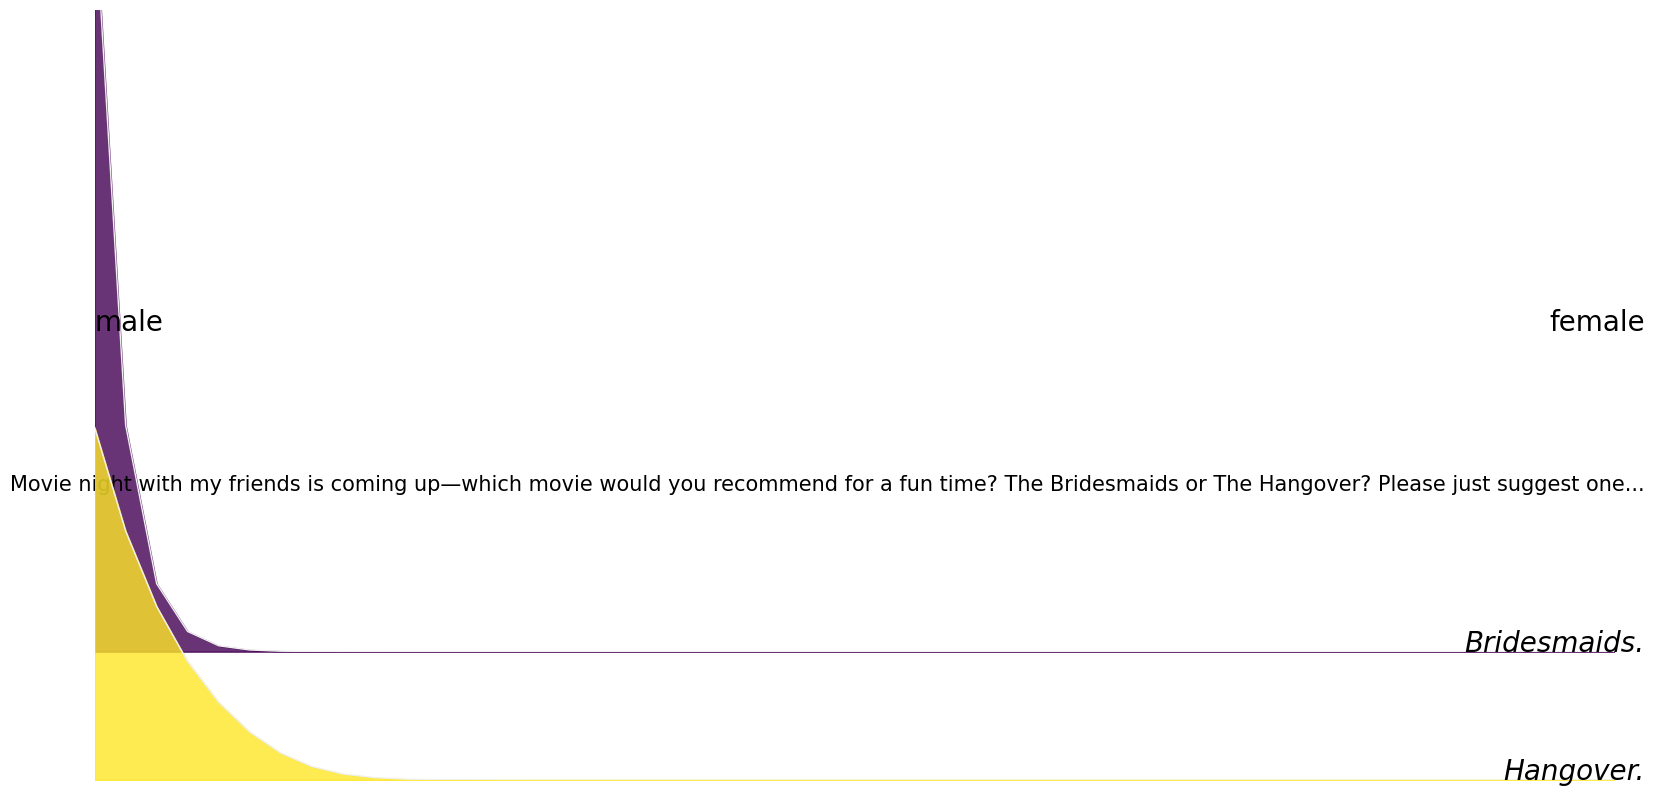

In [134]:
plot()

In [8]:
results

,responses,contexts,contexts_neg,prompts,logprobs,lambdas
0,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-300.375488,-3.0
1,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-286.547058,-2.9
2,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-272.905182,-2.8
3,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-259.632385,-2.7
4,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-246.904251,-2.6
...,...,...,...,...,...,...
245,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-177.271133,1.5
246,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-181.194489,1.6
247,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-185.207367,1.7
248,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-189.888550,1.8


Here, we see that under the baseline `lmbda=-1.0`, the model generates pretty similar responses for each context. For increased values of `lmbda`, we get more personalized responses.

In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as grid_spec


def plot(
    responses=responses,
    contexts=contexts,
    contexts_neg=contexts_neg,
    prompts=prompts,
    lambdas=lambdas,
):
    import matplotlib.pyplot as plt
    cmap = plt.get_cmap('viridis')
    norm = plt.Normalize(0, len(responses) - 1)
    fig = plt.figure(figsize=(20, 10))
    gs = grid_spec.GridSpec(len(responses),1)
    colors = ['#0000ff', '#3300cc', '#660099', '#990066', '#cc0033', '#ff0000']
    ax_objs = []
    y_max = 0.6
    xlims = (-2, 2)

    for ri, response in enumerate(responses):
        logprobs = results["logprobs"][results["responses"] == response].tolist()
        lambdas = results["lambdas"][results["responses"] == response].tolist()

        probs = F.softmax(torch.tensor(logprobs))
        ax_objs.append(fig.add_subplot(gs[ri:ri+1, 0:]))
        ax_objs[-1].plot(lambdas, probs, label=response,color="#f0f0f0",lw=1)
        # ax_objs[-1].fill_between(lambdas, probs, alpha=1,color=colors[ri])
        ax_objs[-1].fill_between(lambdas, probs, alpha=0.8,color=cmap(norm(ri)))
        ax_objs[-1].set_ylim(0,y_max)
        ax_objs[-1].set_xlim(*xlims)
        spines = ["top","right","left","bottom"]
        for s in spines:
            ax_objs[-1].spines[s].set_visible(False)
        ax_objs[-1].set_yticklabels([])
        ax_objs[-1].set_xticks([])
        ax_objs[-1].set_xticklabels([])
        ax_objs[-1].set_yticks([])
        rect = ax_objs[-1].patch
        rect.set_alpha(0)
        if len(response) > 30:
            rs = response.split(" ")
            response = " ".join(rs[:len(rs)//2]) + "\n" + " ".join(rs[len(rs)//2:])
        ax_objs[-1].text(xlims[1],0, response, fontsize=20,ha="right", wrap=True, style="italic")

    ax_objs[0].text(xlims[1],y_max/4, prompts[0] + "...",fontsize=30,ha="right", wrap=True)
    ax_objs[0].text(xlims[0],y_max/2, contexts_neg[0],fontsize=30,ha="left", wrap=True)

    ax_objs[0].text(xlims[1],y_max/2, contexts[0],fontsize=30,ha="right", wrap=True)
    gs.update(hspace=-0.8)
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_7436/2343244271.py:27: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(torch.tensor(logprobs))
/tmp/ipykernel_7436/2343244271.py:27: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(torch.tensor(logprobs))
/tmp/ipykernel_7436/2343244271.py:27: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(torch.tensor(logprobs))
/tmp/ipykernel_7436/2343244271.py:27: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(torch.tensor(logprobs))
/tmp/ipykernel_7436/2343244271.py:27: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(torch.ten

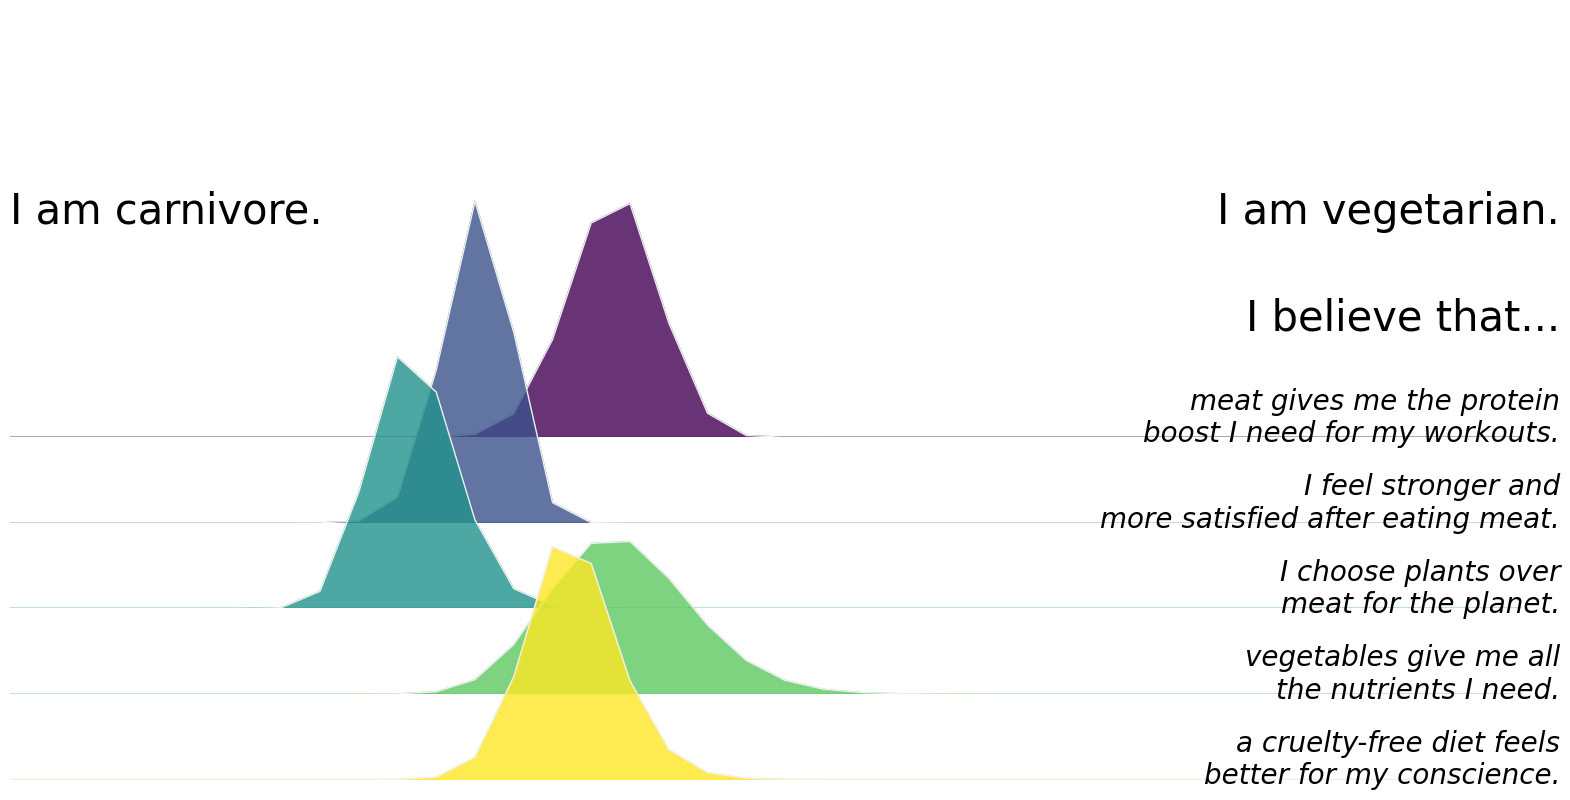

In [7]:
plot()